# Config

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
import json

In [2]:
from openai import OpenAI
import os
client = OpenAI(
    api_key='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',
    base_url="https://api.groq.com/openai/v1",
)
#prompt = "hello world"
#response = client.responses.create(
#    input=prompt,
#    model="openai/gpt-oss-20b",
#)
#print(response.output_text)


# Agents

**Point for discussion**: Query_Agent's prompt point 2 - given that sometimes speeches are written for announcement (e.g. new discovery), these information will not be available online and will be flagged as false. Thus, added point 2 where if the prompt implies/explicitly mentions that it's an announcement, it will skip fact checking for that specific piece of information. To discuss if we want to keep this.

In [3]:
class State(TypedDict):
    graph_state: str
    user_input: str
    query_approved: bool
    query_attempts: int
    query_feedback: str
    plan:str

In [4]:
def Query_Agent(state: State) -> dict:
    user_input = state.get("user_input")
    attempts = state.get("query_attempts",0)

    query_check_prompt = f"""You are a fact-checking agent. 
Based on the details below, your task is to:
1. Check each point mentioned and its supporting example and/or fact for accuracy and relevance to the occassion
2. Some points are groundbreaking announcement that cannot be checked online, do not proceed to check the accuracy of these claim 
3. Return only a JSON object and nothing else

Details: {user_input}

Output Example:
{{
    "approved": true or false,
    "feedback": "<what needs to improve, or empty string if approved>"
}}
"""
    response = client.responses.create(
        input=query_check_prompt,
        model="openai/gpt-oss-20b",
    )
    result = response.output_text
    print(result)
    result = json.loads(response.output_text)
    # raw = response.strip().replace("```json", "").replace("```","")
    # parsed = json.loads(raw)

    return{
        "query_approved": result["approved"],
        "query_feedback": result["feedback"],
        "query_attempts": attempts + 1,
        "user_input": user_input,
    }

In [5]:
def Planner_Agent(state: State) -> dict:
    user_input = state.get("user_input")
    planner_prompt = f"""
You are an expert speech coach.
Your task:
1. Given verified speech details, produce a structured speech plan.
2. estimated_wpm should be between 120 to 150
3. target_word_count should be estimated using time_limit_minutes and estimated_wpm
3. Return ONLY valid JSON. Do not include explanations or text outside the JSON.

Details:
{user_input}

JSON structure:
{{
  "request": {{
    "topic": "",
    "audience": "",
    "occasion": "",
    "time_limit_minutes": "",
  }},
  "targets": {{
    "estimated_wpm": "<to be between 120 to 150>",
    "target_word_count": "<to be defined based on time_limit_minutes and estimated_wpm>"
  }},
  "sections": [
    {{
      "section_id": "S1",
      "name": "",
      "purpose": "",
      "must_include_facts": []
    }}
  ]
}}
"""
    response = client.responses.create(
        input=planner_prompt,
        model="openai/gpt-oss-20b",
    )
    plan = json.loads(response.output_text)
    
    return {"plan": plan}

In [6]:
def collect_user_feedback(topic, audience, occasion, time_limit_in_minutes) -> str:
    revised_content = input("Revised Content to be included (i.e. Point, Examples and Facts):").strip()
    return (
        f"Topic: {topic}\n"
        f"Audience: {audience}\n"
        f"Occasion: {occasion}\n"
        f"Time limit (in minutes): {time_limit_in_minutes}\n\n"
        f"Revised Content:\n{revised_content}"
    )

In [7]:
def Human_Feedback(state: State) -> dict:
    print("\n" + "=" * 50)
    print("FACT-CHECK FAILED — Amendment required")
    print("=" * 50)
    print(f"Feedback: {state.get('query_feedback', 'No feedback provided.')}")
    print()
    print("Please re-enter your speech content with the issues fixed.")

    # Extract existing values from state
    existing_input = state.get("user_input", "")
    parsed = {}
    for line in existing_input.splitlines():
        for key in ["Topic", "Audience", "Occasion", "Time limit (in minutes)"]:
            if line.startswith(f"{key}:"):
                parsed[key] = line[len(f"{key}:"):].strip()

    updated_input = collect_user_feedback(
        topic=parsed.get("Topic", ""),
        audience=parsed.get("Audience", ""),
        occasion=parsed.get("Occasion", ""),
        time_limit_in_minutes=parsed.get("Time limit (in minutes)", ""),
    )

    return {
        "user_input":     updated_input,
        "graph_state":    updated_input,
        "query_approved": False,
        "query_feedback": "",
    }

# Graph Set up 

In [8]:
def route_user(state):
    approved = state.get("query_approved") or state.get("query_attempts", 0) >= 2
    return "approved" if approved else "rejected"

In [9]:
builder = StateGraph(State)
builder.add_node("Query_Agent", Query_Agent)
builder.add_node("Human_Feedback", Human_Feedback)
builder.add_node("Planner_Agent", Planner_Agent)


In [10]:
builder.add_edge(START, "Query_Agent")
builder.add_edge("Human_Feedback", "Query_Agent") 
builder.add_conditional_edges(
    "Query_Agent",
    route_user,
    {
        "approved": "Planner_Agent",
        "rejected": "Human_Feedback" # HITL - needs to go back to user with feedback
    }
)

In [11]:
builder.add_edge("Planner_Agent", END)

In [12]:
graph = builder.compile()

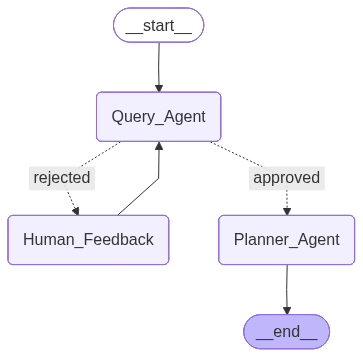

In [13]:
from IPython.display import Image, display
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
def collect_user_input() -> str:
    topic = input("Topic: ").strip()
    audience = input("Audience: ").strip()
    occasion = input("Occasion: ").strip()
    time_limit_in_minutes = input("Time limit (in minutes): ").strip()
    content = input("Content to be included (i.e. Point, Examples and Facts):").strip()

 
    return (
        f"Topic: {topic}\n"
        f"Audience: {audience}\n"
        f"Occasion: {occasion}\n"
        f"Time limit (in minutes): {time_limit_in_minutes}\n\n"
        f"Content:\n{content}"
    )

In [ ]:
def main():
    print("Speech Generator ready. Type 'quit' at any prompt to exit.\n")
 
    while True:
        try:
            user_input = collect_user_input()
        except (KeyboardInterrupt, EOFError):
            print("\nGoodbye!")
            break
 
        if user_input.strip().lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
 
        if not user_input.strip():
            continue
 
        print("\nChecking your content...\n")
 
        state: State = {
            "graph_state": user_input,
            "user_input": user_input,
            "query_approved": False,
            "query_attempts": 0,
            "query_feedback": "",
            "plan": "",
        }
 
        result = graph.invoke(state)
 
        # Surface feedback if fact-check hit the attempt limit without approving
        if not result.get("query_approved") and result.get("query_feedback"):
            print("Note: Some content could not be verified but the plan was generated anyway.")
            print(f"Feedback: {result['query_feedback']}\n")
 
        print("\n" + "=" * 50)
        print("YOUR SPEECH PLAN")
        print("=" * 50)
        print(result.get("plan", "No plan generated."))
        print()
 
        again = input("Generate another speech? (y/n): ").strip().lower()
        if again != "y":
            print("Goodbye!")
            break
 
 
if __name__ == "__main__":
    main()

Speech Generator ready. Type 'quit' at any prompt to exit.



Topic:  How Artificial Intelligence is Transforming Manufacturing Excellence
Audience:   Global manufacturing leaders, plant managers, and engineering teams
Occasion:  BMW Group Global Manufacturing Summit 2026 – Opening Keynote
Time limit (in minutes):  6
Content to be included (i.e. Point, Examples and Facts): Start with a hook including A concrete, sensory manufacturing scene and include A one-line thesis that links AI to excellence. Also, talk about the impact of AI where Smart manufacturing has raised productivity by 70% and Singapore has modernized in the past to our benefit, becoming one of the 4 Asian Tigers. Lastly, end it with a call-to-action and closing, make it forward looking with a memorable closing line



Checking your content...

{
    "approved": false,
    "feedback": "The statement that \"Smart manufacturing has raised productivity by 70%\" lacks a verifiable source and may misrepresent the actual impact. Consider citing a specific study or using a more conservative estimate. The claim that Singapore has modernized and is one of the four Asian Tigers is broadly correct, but the phrase \"to our benefit\" is vague and should be clarified or supported with context."
}

FACT-CHECK FAILED — Amendment required
Feedback: The statement that "Smart manufacturing has raised productivity by 70%" lacks a verifiable source and may misrepresent the actual impact. Consider citing a specific study or using a more conservative estimate. The claim that Singapore has modernized and is one of the four Asian Tigers is broadly correct, but the phrase "to our benefit" is vague and should be clarified or supported with context.

Please re-enter your speech content with the issues fixed.


Revised Content to be included (i.e. Point, Examples and Facts): Start with a hook including a concrete, sensory manufacturing scene and include a one-line thesis that links AI to excellence. Also, talk about the impact of AI where BMW is proud to announce that smart manufacturing has raised productivity by 70% and Singapore has modernized in the past to our benefit, becoming one of the 4 Asian Tigers. Lastly, end it with a call-to-action and closing, make it forward looking with a memorable closing line


{"approved": false, "feedback": "The claim that BMW’s smart manufacturing has raised productivity by 70% is unverified and likely inaccurate; no public source confirms this figure. The rest of the content is relevant to the audience and occasion, but this claim should be corrected or removed before presentation."}
Note: Some content could not be verified but the plan was generated anyway.
Feedback: The claim that BMW’s smart manufacturing has raised productivity by 70% is unverified and likely inaccurate; no public source confirms this figure. The rest of the content is relevant to the audience and occasion, but this claim should be corrected or removed before presentation.


YOUR SPEECH PLAN
{'request': {'topic': 'How Artificial Intelligence is Transforming Manufacturing Excellence', 'audience': 'Global manufacturing leaders, plant managers, and engineering teams', 'occasion': 'BMW Group Global Manufacturing Summit 2026 – Opening Keynote', 'time_limit_minutes': 6}, 'targets': {'estima

Generate another speech? (y/n):  y
Topic:  quit
